# 📅 Class 11.1 — Time Series Components & Stationarity
### 301 – ML Techniques | Week 11

**Learning Goals:**
- Decompose time series into trend, seasonality, cyclical, residual
- Test for stationarity with the ADF test
- Apply log transformation and first differencing to achieve stationarity
- **NEVER** use random train_test_split on time series — always chronological split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
print('✅ Ready')
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

✅ Ready


---
## ⚠️ CRITICAL RULE — Read Before Starting

```
NEVER: train_test_split(X, y, ...shuffle=True...)  ← DESTROYS time order!
ALWAYS: chronological split
    split_idx = int(len(df) * 0.8)
    train = df.iloc[:split_idx]
    test  = df.iloc[split_idx:]
```

Shuffle on time series = data leakage. Future data leaks into training.

In [2]:
# Load Airline Passengers dataset (classic time series benchmark)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Passengers']

print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0]} to {df.index[-1]}')
print(df.head(12))

Shape: (144, 1)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
1949-06-01         135
1949-07-01         148
1949-08-01         148
1949-09-01         136
1949-10-01         119
1949-11-01         104
1949-12-01         118


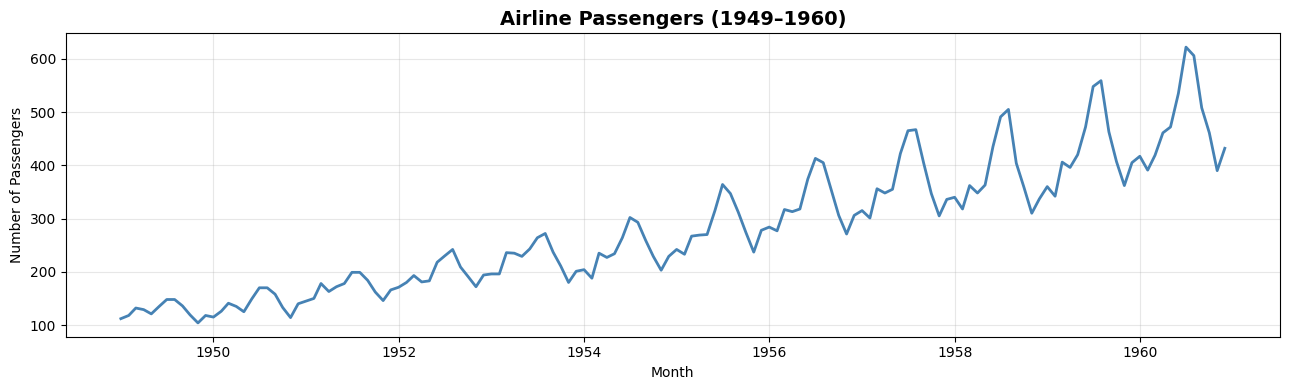

Visual inspection questions:
1. Is there an upward trend?  Answer: Yes — passenger numbers grow steadily from 1949 to 1960.
2. Is there seasonality (repeating pattern)?  Answer: Yes — a clear yearly pattern with peaks
   in summer travel months.
3. Does the seasonal variation grow over time?  Answer: Yes — the amplitude of the seasonal
   peaks gets larger as the trend rises.
   (If yes: multiplicative decomposition; if no: additive)


In [3]:
# Plot raw time series
plt.figure(figsize=(13, 4))
plt.plot(df.index, df['Passengers'], color='steelblue', linewidth=2)
plt.title('Airline Passengers (1949–1960)', fontsize=14, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Number of Passengers')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Visual inspection questions:')
print('1. Is there an upward trend?  Answer: Yes — passenger numbers grow steadily from 1949 to 1960.')
print('2. Is there seasonality (repeating pattern)?  Answer: Yes — a clear yearly pattern with peaks')
print('   in summer travel months.')
print('3. Does the seasonal variation grow over time?  Answer: Yes — the amplitude of the seasonal')
print('   peaks gets larger as the trend rises.')
print('   (If yes: multiplicative decomposition; if no: additive)')


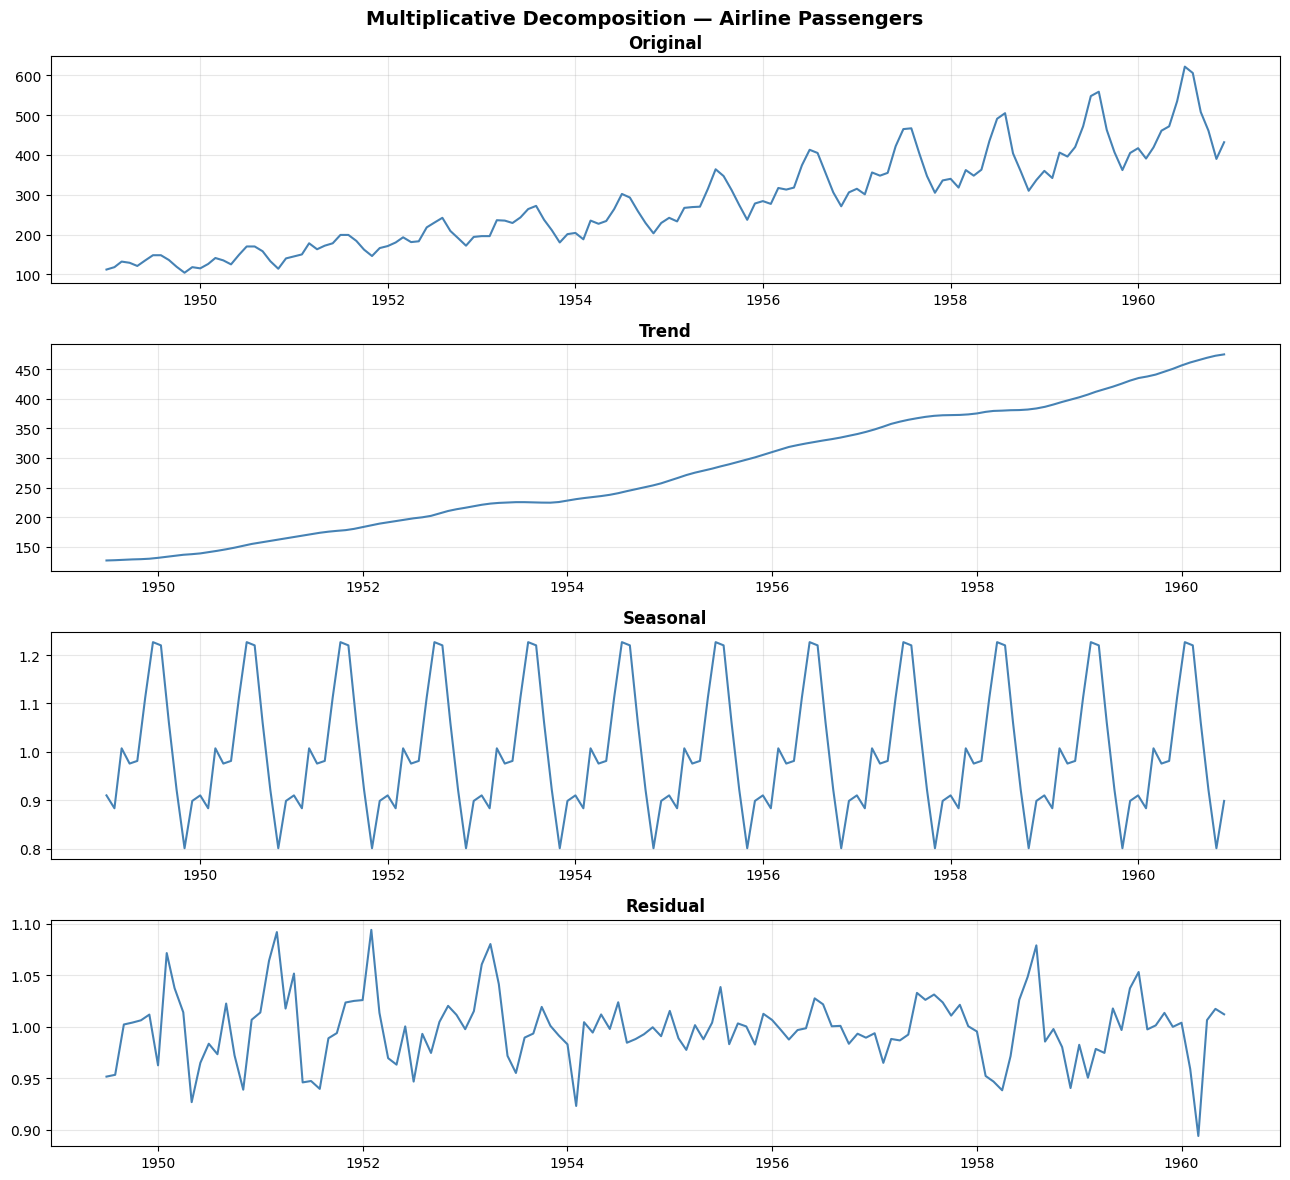

In [4]:
# Seasonal decomposition
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 12))
for ax, data, label in zip(axes,
    [df['Passengers'], result.trend, result.seasonal, result.resid],
    ['Original', 'Trend', 'Seasonal', 'Residual']):
    ax.plot(data, color='steelblue', linewidth=1.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
plt.suptitle('Multiplicative Decomposition — Airline Passengers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [5]:
# Stationarity — ADF test
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    p_val = result[1]
    print(f'{name}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value      : {p_val:.4f}')
    if p_val < 0.05:
        print(f'  → STATIONARY (p < 0.05 — reject H0 of unit root)')
    else:
        print(f'  → NON-STATIONARY (p ≥ 0.05 — fail to reject H0)')
    print()
    return p_val < 0.05

print('=== ADF Tests ===')
is_stat = adf_test(df['Passengers'], 'Original series')

# Apply log transformation (stabilise variance)
df['log_passengers'] = np.log(df['Passengers'])
is_stat_log = adf_test(df['log_passengers'], 'Log-transformed')

# Apply first differencing (remove trend)
df['diff_log'] = df['log_passengers'].diff()
is_stat_diff = adf_test(df['diff_log'].dropna(), 'Log + First Difference')

print('Summary:')
print(f'  Original:        Stationary = {is_stat}')
print(f'  Log transform:   Stationary = {is_stat_log}')
print(f'  Log + diff:      Stationary = {is_stat_diff}')


=== ADF Tests ===
Original series:
  ADF Statistic: 0.8154
  p-value      : 0.9919
  → NON-STATIONARY (p ≥ 0.05 — fail to reject H0)

Log-transformed:
  ADF Statistic: -1.7170
  p-value      : 0.4224
  → NON-STATIONARY (p ≥ 0.05 — fail to reject H0)

Log + First Difference:
  ADF Statistic: -2.7171
  p-value      : 0.0711
  → NON-STATIONARY (p ≥ 0.05 — fail to reject H0)

Summary:
  Original:        Stationary = False
  Log transform:   Stationary = False
  Log + diff:      Stationary = False


---
## ✅ Complete!

- **Stationarity**: mean and variance constant over time — required by many TS models
- **ADF test**: p < 0.05 → stationary
- **Log transform**: stabilises multiplicative seasonality
- **First difference**: removes trend
- **CRITICAL**: NEVER shuffle time series data for train/test split